In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import itertools #FOr confusion matrix
import warnings
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('/content/malicious_phish.csv')
df.head()

,url,type
0,br-icloud.com.br,phishing
1,mp3raid.com/music/krizz_kaliko.html,benign
2,bopsecrets.org/rexroth/cr/1.htm,benign
3,http://www.garage-pirenne.be/index.php?option=...,defacement
4,http://adventure-nicaragua.net/index.php?optio...,defacement


In [ ]:
df.shape

(651191, 2)

In [ ]:
df.type.value_counts()

,count
type,
benign,428103
defacement,96457
phishing,94111
malware,32520


In [ ]:
import re
#USe of IP or not in domain
def having_ip_address(url):
    match = re.search(
     '(([01]?\\d\\d?|2[0-4]\\d|25[0-5])\\.([01]?\\d\\d?|2[0-4]\\d|25[0-5])\\.([01]?\\d\\d?|2[0-4]\\d|25[0-5])\\.'
        '([01]?\\d\\d?|2[0-4]\\d|25[0-5])\\/)|'  # IPv4
        '((0x[0-9a-fA-F]{1,2})\\.(0x[0-9a-fA-F]{1,2})\\.(0x[0-9a-fA-F]{1,2})\\.(0x[0-9a-fA-F]{1,2})\\/)' # IPv4 in hexadecimal
        '(?:[a-fA-F0-9]{1,4}:){7}[a-fA-F0-9]{1,4}', url) # Ipv6

    if match:
        #Print match.group
        return 1
    else:
        #print no matching pattern found
        return 0

df['use_of_ip'] = df['url'].apply(lambda i: having_ip_address(i))

In [ ]:
from urllib.parse import urlparse
def abnormal_url(url):
    hostname = urlparse(url).hostname
    hostname=str(hostname)
    match = re.search(hostname,url)
    if match:
        #print match.group
        return 1
    else:
        #Print no matching patterns found
        return 0

df['abnormal_url'] = df['url'].apply(lambda i: abnormal_url(i))


In [ ]:
!pip install googlesearch-python

In [ ]:
from googlesearch import search

def google_index(url):
    site = search(url,5)
    return 1 if site else 0

df['google_index'] = df['url'].apply(lambda i: google_index(i))

In [ ]:
def count_dot(url):
    count_dot = url.count('.')
    return count_dot

df['count. '] = df['url'].apply(lambda i: count_dot(i))
df.head()

,url,type,use_of_ip,abnormal_url,google_index,count.
0,br-icloud.com.br,phishing,0,0,1,2
1,mp3raid.com/music/krizz_kaliko.html,benign,0,0,1,2
2,bopsecrets.org/rexroth/cr/1.htm,benign,0,0,1,2
3,http://www.garage-pirenne.be/index.php?option=...,defacement,0,1,1,3
4,http://adventure-nicaragua.net/index.php?optio...,defacement,0,1,1,2


In [ ]:
def count_www(url):
    url.count('www')
    return url.count('www')

df['count-www'] = df['url'].apply(lambda i: count_www(i))

def count_atrate(url):
    return url.count('@')

df['count@'] = df['url'].apply(lambda i: count_atrate(i))

def no_of_dir(url):
    urldir = urlparse(url).path
    return urldir.count('/')

df['count_dir'] = df['url'].apply(lambda i : no_of_dir(i))

def no_of_embed(url):
    urldir = urlparse(url).path
    return urldir.count('//')

df['count_embed_domain'] = df['url'].apply(lambda i: no_of_embed(i))

def shortening_service(url):
    match = re.search('bit\.ly|goo\.gl|shorte\.st|go2l\.ink|x\.co|ow\.ly|t\.co|tinyurl|tr\.im|is\.gd|cli\.gs|'
                      'yfrog\.com|migre\.me|ff\.im|tiny\.cc|url4\.eu|twit\.ac|su\.pr|twurl\.nl|snipurl\.com|'
                      'short\.to|BudURL\.com|ping\.fm|post\.ly|Just\.as|bkite\.com|snipr\.com|fic\.kr|loopt\.us|'
                      'doiop\.com|short\.ie|kl\.am|wp\.me|rubyurl\.com|om\.ly|to\.ly|bit\.do|t\.co|lnkd\.in|'
                      'db\.tt|qr\.ae|adf\.ly|goo\.gl|bitly\.com|cur\.lv|tinyurl\.com|ow\.ly|bit\.ly|ity\.im|'
                      'q\.gs|is\.gd|po\.st|bc\.vc|twitthis\.com|u\.to|j\.mp|buzurl\.com|cutt\.us|u\.bb|yourls\.org|'
                      'x\.co|prettylinkpro\.com|scrnch\.me|filoops\.info|vzturl\.com|qr\.net|1url\.com|tweez\.me|v\.gd|'
                      'tr\.im|link\.zip\.net',
                      url)

    if match:
        return 1
    else:
        return 0

df['short_url'] = df ['url'].apply(lambda i: shortening_service(i))

In [ ]:
df.head()

,url,type,use_of_ip,abnormal_url,google_index,count.,count-www,count@,count_dir,count_embed_domain,short_url
0,br-icloud.com.br,phishing,0,0,1,2,0,0,0,0,0
1,mp3raid.com/music/krizz_kaliko.html,benign,0,0,1,2,0,0,2,0,0
2,bopsecrets.org/rexroth/cr/1.htm,benign,0,0,1,2,0,0,3,0,0
3,http://www.garage-pirenne.be/index.php?option=...,defacement,0,1,1,3,1,0,1,0,0
4,http://adventure-nicaragua.net/index.php?optio...,defacement,0,1,1,2,0,0,1,0,0


In [ ]:
def count_https(url):
    return url.count('https')

df['count-https'] = df['url'].apply(lambda i: count_https(i))

def count_http(url):
    return url.count('http')

df['count-http'] = df['url'].apply(lambda i: count_http(i))

def count_per(url):
    return url.count('%')

df['count%'] = df['url'].apply(lambda i: count_per(i))

def count_ques(url):
    return url.count('?')

df['count?'] = df['url'].apply(lambda i: count_ques(i))

def count_hyphen(url):
    return url.count('-')
df['count-'] = df['url'].apply(lambda i: count_hyphen(i)).astype(int)

def count_equal(url):
    return url.count('=')

df['count=']= df['url'].apply(lambda i: count_equal(i))

def url_length(url):
    return len(str(url))

#length of URL
df['url_length'] = df['url'].apply(lambda i : url_length(i))

#Host name length
def hostname_length(url):
    return len(urlparse(url).netloc)

df['hostname_length'] = df['url'].apply(lambda i: hostname_length(i))
df.head()

,url,type,use_of_ip,abnormal_url,google_index,count.,count-www,count@,count_dir,count_embed_domain,short_url,count-https,count-http,count%,count?,count-,count=,url_length,hostname_length
0,br-icloud.com.br,phishing,0,0,1,2,0,0,0,0,0,0,0,0,0,1,0,16,0
1,mp3raid.com/music/krizz_kaliko.html,benign,0,0,1,2,0,0,2,0,0,0,0,0,0,0,0,35,0
2,bopsecrets.org/rexroth/cr/1.htm,benign,0,0,1,2,0,0,3,0,0,0,0,0,0,0,0,31,0
3,http://www.garage-pirenne.be/index.php?option=...,defacement,0,1,1,3,1,0,1,0,0,0,1,0,1,1,4,88,21
4,http://adventure-nicaragua.net/index.php?optio...,defacement,0,1,1,2,0,0,1,0,0,0,1,0,1,1,3,235,23


In [ ]:
def suspicious_words(url):
    match = re.search('PayPal|logins|signin|bank|account|update|free|lucky|service|bonus|ebayisapi|webscr',url)
    if match:
        return 1
    else:
        return 0

df['sus_url'] = df['url'].apply(lambda i: suspicious_words(i))

def digit_count(url):
        digits = 0
        for i in url:
            if i.isnumeric():
                digits = digits + 1
        return digits # Moved return outside the loop
df['count_digits'] = df['url'].apply(lambda i: digit_count(i))

def letter_count(url):
    letters = 0
    for i in url:
        if i.isalpha():
            letters = letters + 1
    return letters # Moved return outside the loop

df['count-letters']  = df['url'].apply(lambda i : letter_count(i))
df.head()

,url,type,use_of_ip,abnormal_url,google_index,count.,count-www,count@,count_dir,count_embed_domain,...,count-http,count%,count?,count-,count=,url_length,hostname_length,sus_url,count_digits,count-letters
0,br-icloud.com.br,phishing,0,0,1,2,0,0,0,0,...,0,0,0,1,0,16,0,0,0,13
1,mp3raid.com/music/krizz_kaliko.html,benign,0,0,1,2,0,0,2,0,...,0,0,0,0,0,35,0,0,1,29
2,bopsecrets.org/rexroth/cr/1.htm,benign,0,0,1,2,0,0,3,0,...,0,0,0,0,0,31,0,0,1,25
3,http://www.garage-pirenne.be/index.php?option=...,defacement,0,1,1,3,1,0,1,0,...,1,0,1,1,4,88,21,0,7,63
4,http://adventure-nicaragua.net/index.php?optio...,defacement,0,1,1,2,0,0,1,0,...,1,0,1,1,3,235,23,0,22,199


In [ ]:
!pip install tLd

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 10.5 MB/s eta 0:00:00


In [ ]:
from urllib.parse import urlparse
from tld import get_tld
import os.path

#first directory length
def fd_length(url):
    urlpath = urlparse(url).path
    try:
        return len(urlpath.split('/')[1])
    except:
        return 0

df['fd_length'] = df['url'].apply(lambda i:fd_length(i))

#LEngth of top level domain
df['tld'] = df['url'].apply(lambda i: get_tld(i,fail_silently=True))

def tld_length(tld):
    try:
        return len(tld)
    except:
        return -1

df['tld_length'] = df['tld'].apply(lambda i: tld_length(i))
df = df.drop(['tld'],axis=1)
df.head()

,url,type,use_of_ip,abnormal_url,google_index,count.,count-www,count@,count_dir,count_embed_domain,...,count?,count-,count=,url_length,hostname_length,sus_url,count_digits,count-letters,fd_length,tld_length
0,br-icloud.com.br,phishing,0,0,1,2,0,0,0,0,...,0,1,0,16,0,0,0,13,0,-1
1,mp3raid.com/music/krizz_kaliko.html,benign,0,0,1,2,0,0,2,0,...,0,0,0,35,0,0,1,29,5,-1
2,bopsecrets.org/rexroth/cr/1.htm,benign,0,0,1,2,0,0,3,0,...,0,0,0,31,0,0,1,25,7,-1
3,http://www.garage-pirenne.be/index.php?option=...,defacement,0,1,1,3,1,0,1,0,...,1,1,4,88,21,0,7,63,9,2
4,http://adventure-nicaragua.net/index.php?optio...,defacement,0,1,1,2,0,0,1,0,...,1,1,3,235,23,0,22,199,9,3


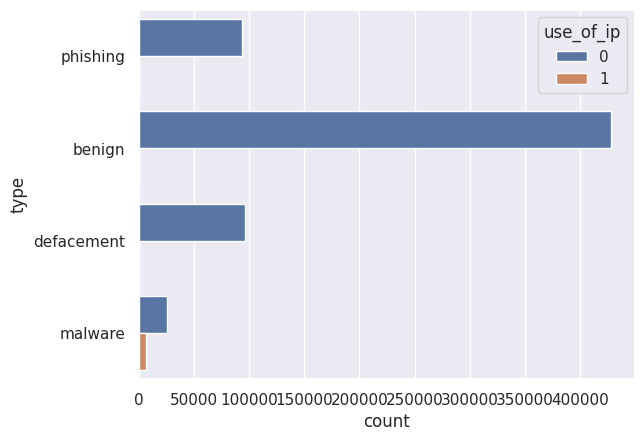

In [ ]:
#Dist of use_of_ip
sns.set(style='darkgrid')
ax = sns.countplot(y='type',data=df,hue='use_of_ip')

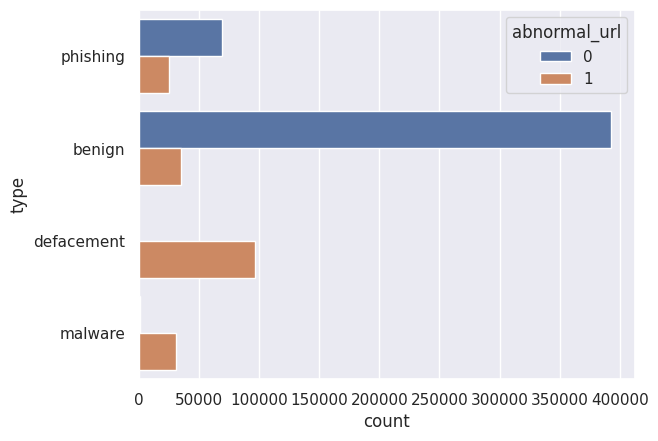

In [ ]:
#dist of abnormal url
sns.set(style='darkgrid')
ax=sns.countplot(y='type',data=df,hue='abnormal_url')

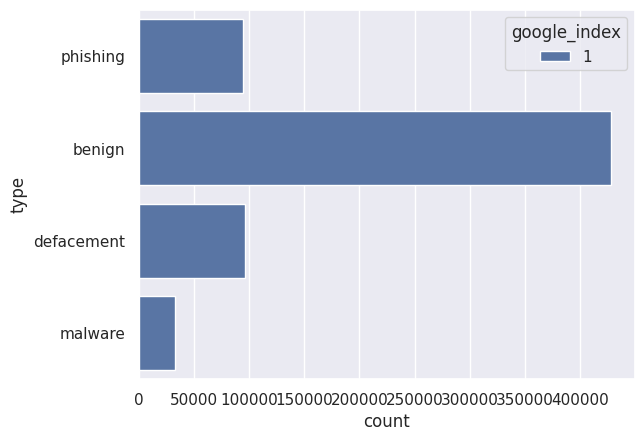

In [ ]:
#dist of google inddex
sns.set(style='darkgrid')
ax = sns.countplot(y='type',data=df,hue='google_index')


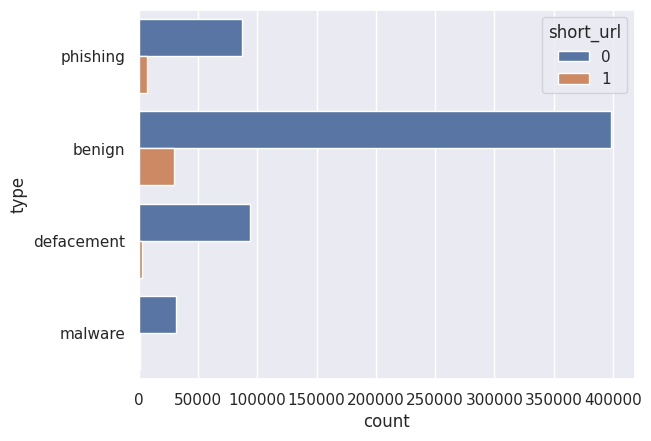

In [ ]:
#Dist of short url
sns.set(style='darkgrid')
ax = sns.countplot(y='type',data=df,hue='short_url')

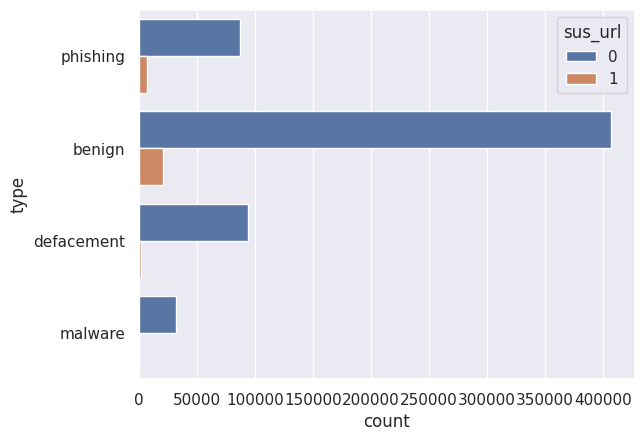

In [ ]:
#DIst of suspicious URL
sns.set(style='darkgrid')
ax=sns.countplot(y='type',data=df,hue='sus_url')

In [ ]:
df.columns

Index(['url', 'type', 'use_of_ip', 'abnormal_url', 'google_index', 'count. ',
       'count-www', 'count@', 'count_dir', 'count_embed_domain', 'short_url',
       'count-https', 'count-http', 'count%', 'count?', 'count-', 'count=',
       'url_length', 'hostname_length', 'sus_url', 'count_digits',
       'count-letters', 'fd_length', 'tld_length'],
      dtype='object')

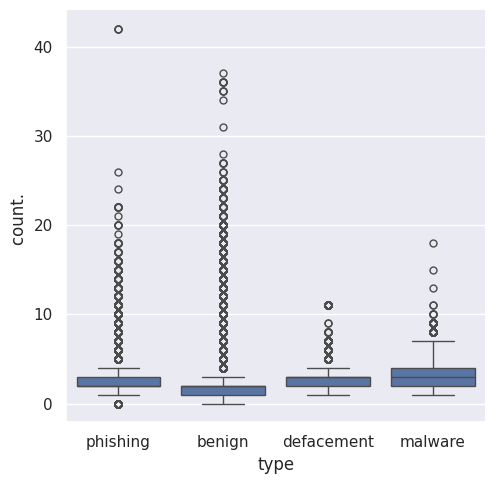

In [ ]:
#Dist of count of [.] dot
sns.set(style='darkgrid')
ax = sns.catplot(x='type',y='count. ',kind='box',data=df)


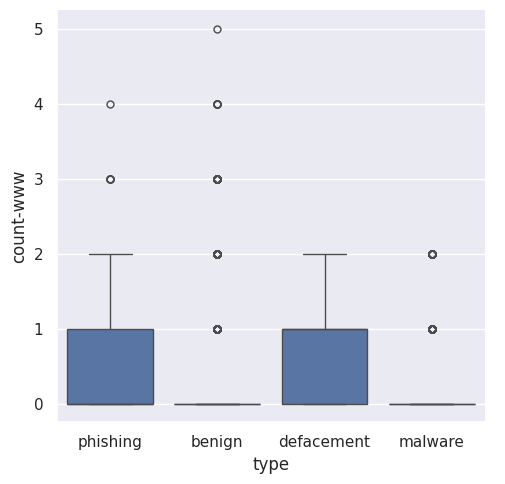

In [ ]:
#Dist of count-www
sns.set(style='darkgrid')
ax=sns.catplot(x='type',y='count-www',kind='box',data=df)

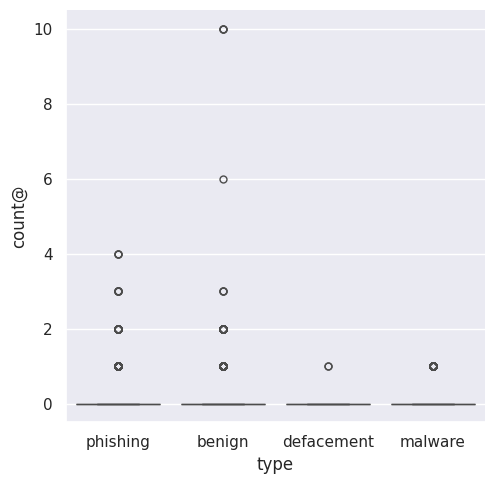

In [ ]:
#Dist pf count@
sns.set(style='darkgrid')
ax= sns.catplot(x='type',y='count@',kind='box',data=df)

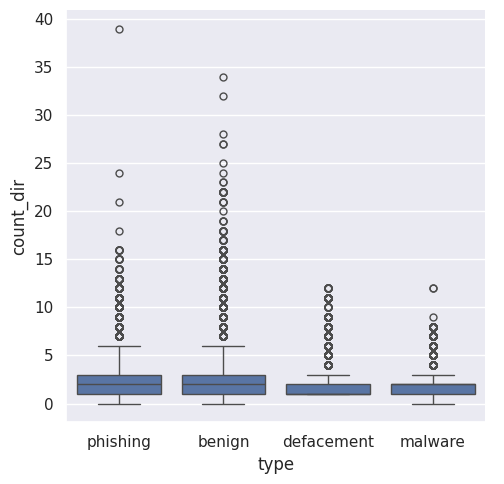

In [ ]:
#Dist pf count_dir
sns.set(style='darkgrid')
ax= sns.catplot(x='type',y='count_dir',kind='box',data=df)

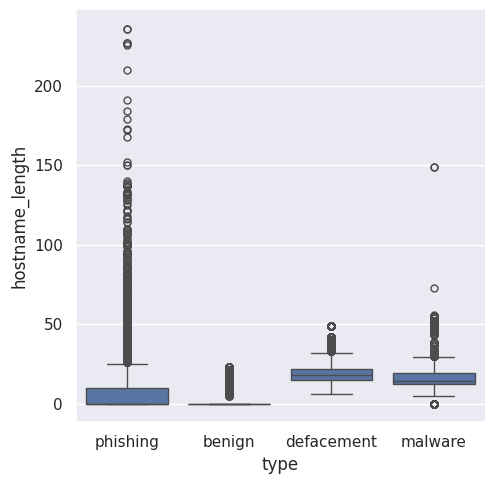

In [ ]:
#Dist of hostname length
sns.set(style='darkgrid')
ax= sns.catplot(x='type',y='hostname_length',kind='box',data=df)

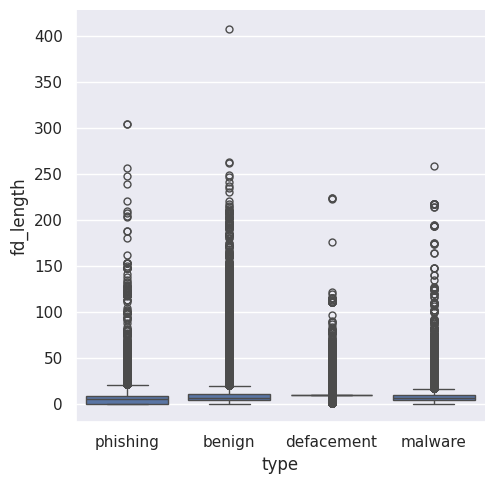

In [ ]:
#Dist of first directory length
sns.set(style='darkgrid')
ax= sns.catplot(x='type',y='fd_length',kind='box',data=df)

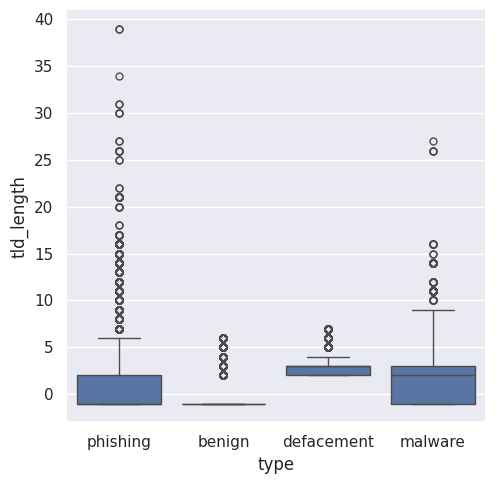

In [ ]:
#Dist of top level domain
sns.set(style='darkgrid')
ax= sns.catplot(x='type',y='tld_length',kind='box',data=df)

In [ ]:

#Target encoding
from sklearn.preprocessing import LabelEncoder
lb_make = LabelEncoder()
df['type_code'] = lb_make.fit_transform(df['type'])
df['type_code'].value_counts()

,count
type_code,
0,428103
1,96457
3,94111
2,32520


In [ ]:
#Predictor variables
#Filtering out google)index as it has only 1 value
x = df[['use_of_ip', 'abnormal_url', 'google_index', 'count. ',
       'count-www', 'count@', 'count_dir', 'count_embed_domain', 'short_url',
       'count-https', 'count-http', 'count%', 'count?', 'count=',
       'url_length', 'hostname_length', 'sus_url', 'count_digits',
       'count-letters', 'fd_length', 'tld_length']]

y = df['type_code']


In [ ]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 651191 entries, 0 to 651190
Data columns (total 25 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   url                 651191 non-null  object
 1   type                651191 non-null  object
 2   use_of_ip           651191 non-null  int64 
 3   abnormal_url        651191 non-null  int64 
 4   google_index        651191 non-null  int64 
 5   count.              651191 non-null  int64 
 6   count-www           651191 non-null  int64 
 7   count@              651191 non-null  int64 
 8   count_dir           651191 non-null  int64 
 9   count_embed_domain  651191 non-null  int64 
 10  short_url           651191 non-null  int64 
 11  count-https         651191 non-null  int64 
 12  count-http          651191 non-null  int64 
 13  count%              651191 non-null  int64 
 14  count?              651191 non-null  int64 
 15  count-              651191 non-null  int64 
 16  co

In [ ]:

#MOdel building
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,stratify=y,test_size=0.2,shuffle=True,random_state=5)

x_train_scaled = x_train
x_test_scaled = x_test
#model selections

from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
#objects

rf = RandomForestClassifier(n_estimators=100,max_features='sqrt')


In [ ]:
import warnings
warnings.filterwarnings('ignore')

rf.fit(x_train_scaled,y_train)


RandomForestClassifier()

In [ ]:
#preds

rfpred = rf.predict(x_test_scaled)
#Evaluations
from sklearn.metrics import accuracy_score

rfacc = accuracy_score(y_test,rfpred)
print('RANDOM FOREST',rfacc)

RANDOM FOREST 0.9644960418922135


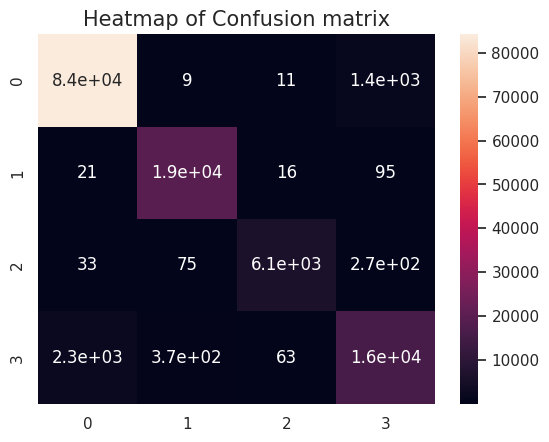

In [ ]:
from sklearn.metrics import confusion_matrix,classification_report
cm = confusion_matrix(y_test,rfpred)
plt.title('Heatmap of Confusion matrix',fontsize=15)
sns.heatmap(cm,annot=True)
plt.show()

In [ ]:
#NOWw we will check the classification report
print(classification_report(y_test,rfpred))

              precision    recall  f1-score   support

           0       0.97      0.98      0.98     85621
           1       0.98      0.99      0.98     19292
           2       0.99      0.94      0.96      6504
           3       0.90      0.85      0.88     18822

    accuracy                           0.96    130239
   macro avg       0.96      0.94      0.95    130239
weighted avg       0.96      0.96      0.96    130239



In [ ]:
import joblib
from google.colab import files

# Model save karna
file_name = "random_forest_model.joblib"
joblib.dump(rf, file_name)

# PC mein download karna
files.download(file_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd

# 1. Labels mapping (Aapke dataset ke mutabiq)
# Agar aapke labels 0, 1, 2 hain to unhe naam de dete hain
label_names = {0: 'Benign', 1: 'Defacement', 2: 'Phishing'}

# 2. Aik DataFrame banate hain comparison ke liye
results_df = pd.DataFrame({
    'Actual Label': y_test,
    'Predicted Label': rfpred
})

# 3. Numbers ko names mein convert karein
results_df['Actual Name'] = results_df['Actual Label'].map(label_names)
results_df['Predicted Name'] = results_df['Predicted Label'].map(label_names)

# 4. Ye check karein ke prediction sahi hai ya nahi
results_df['Correct?'] = results_df['Actual Label'] == results_df['Predicted Label']

# 5. Pehli 20 predictions dekhte hain
print("--- Model Prediction vs Actual ---")
print(results_df[['Actual Name', 'Predicted Name', 'Correct?']].head(20))

# 6. Summary: Kitne sahi aur kitne galat huay
print("\n--- Summary ---")
print(results_df['Correct?'].value_counts())

--- Model Prediction vs Actual ---
       Actual Name Predicted Name  Correct?
120468  Defacement     Defacement      True
548284    Phishing       Phishing      True
382779      Benign         Benign      True
572484      Benign         Benign      True
418950      Benign         Benign      True
527138         NaN            NaN      True
193196      Benign         Benign      True
414153      Benign         Benign      True
315927      Benign         Benign      True
445156  Defacement     Defacement      True
469695      Benign         Benign      True
436162      Benign         Benign      True
297244      Benign         Benign      True
377181         NaN            NaN      True
637515         NaN         Benign     False
219933      Benign         Benign      True
545560    Phishing       Phishing      True
272168    Phishing       Phishing      True
272734      Benign         Benign      True
362281  Defacement     Defacement      True

--- Summary ---
Correct?
True     125615

In [ ]:
from urllib.parse import urlparse
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import LabelEncoder

# Target encoding: Add 'type_code' to df before splitting
lb_make = LabelEncoder()
df['type_code'] = lb_make.fit_transform(df['type'])

# Extract domain from URL
def get_domain(url):
    try:
        netloc = urlparse(url).netloc
        return netloc.replace('www.', '')
    except:
        return url

df['domain'] = df['url'].apply(get_domain)

print(f"Total rows: {len(df)}, Unique domains: {df['domain'].nunique()}")

# Group split by domain so same domain never appears in both train and test
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(df, groups=df['domain']))

train_df = df.iloc[train_idx]
test_df = df.iloc[test_idx]

# Sanity check — this must print True
overlap = set(train_df['domain']) & set(test_df['domain'])
print(f"Overlapping domains between train/test: {len(overlap)} (should be 0)")

feature_cols = [c for c in df.columns if c not in ['url', 'domain', 'type_code', 'type', 'registrable_domain']]
X_train, y_train = train_df[feature_cols], train_df['type_code']
X_test, y_test = test_df[feature_cols], test_df['type_code']

from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

from sklearn.metrics import accuracy_score, classification_report
rf_preds = rf.predict(X_test)
print("RF Domain-Unseen Accuracy:", accuracy_score(y_test, rf_preds))
print(classification_report(y_test, rf_preds))

Total rows: 651191, Unique domains: 21521
Overlapping domains between train/test: 0 (should be 0)
RF Domain-Unseen Accuracy: 0.8779810336120307
              precision    recall  f1-score   support

           0       0.93      0.78      0.85      6649
           1       0.95      0.94      0.94     20015
           2       0.97      0.74      0.84      3976
           3       0.61      0.89      0.72      5002

    accuracy                           0.88     35642
   macro avg       0.86      0.84      0.84     35642
weighted avg       0.90      0.88      0.88     35642



In [ ]:
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler

# Scale for SVM and MLP only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

xgb = XGBClassifier(eval_metric='logloss', random_state=42)
xgb.fit(X_train, y_train)
xgb_preds = xgb.predict(X_test)

svm = SVC(probability=True, random_state=42)
svm.fit(X_train_scaled, y_train)
svm_preds = svm.predict(X_test_scaled)

mlp = MLPClassifier(hidden_layer_sizes=(64,32), max_iter=500, random_state=42)
mlp.fit(X_train_scaled, y_train)
mlp_preds = mlp.predict(X_test_scaled)

results = {
    'Random Forest': accuracy_score(y_test, rf_preds),
    'XGBoost': accuracy_score(y_test, xgb_preds),
    'SVM': accuracy_score(y_test, svm_preds),
    'MLP': accuracy_score(y_test, mlp_preds),
}
for name, acc in results.items():
    print(f"{name}: {acc:.4f}")

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from scipy.stats import ttest_rel

X_all = df[feature_cols]
y_all = df['type_code'] # Changed from 'label' to 'type_code'

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

rf_scores = cross_val_score(rf, X_all, y_all, cv=skf, scoring='accuracy')

# For SVM/MLP, scale inside a pipeline so scaling doesn't leak across folds
from sklearn.pipeline import make_pipeline
svm_pipe = make_pipeline(StandardScaler(), SVC(random_state=42))
mlp_pipe = make_pipeline(StandardScaler(), MLPClassifier(hidden_layer_sizes=(64,32), max_iter=500, random_state=42))

xgb_scores = cross_val_score(xgb, X_all, y_all, cv=skf, scoring='accuracy')
svm_scores = cross_val_score(svm_pipe, X_all, y_all, cv=skf, scoring='accuracy')
mlp_scores = cross_val_score(mlp_pipe, X_all, y_all, cv=skf, scoring='accuracy')

for name, scores in [('XGBoost', xgb_scores), ('SVM', svm_scores), ('MLP', mlp_scores)]:
    t_stat, p_val = ttest_rel(rf_scores, scores)
    sig = "significant" if p_val < 0.05 else "NOT significant"
    print(f"RF vs {name}: t={t_stat:.3f}, p={p_val:.4f} ({sig})")

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve, auc

# Binarize y_test for class 1 (Defacement) to use with ROC and PR curves
# The predict_proba[:,1] extracts probabilities for class 1.
y_test_binary_class1 = (y_test == 1).astype(int)

models_probs = {
    'Random Forest': rf.predict_proba(X_test)[:,1],
    'XGBoost': xgb.predict_proba(X_test)[:,1],
    'SVM': svm.predict_proba(X_test_scaled)[:,1],
    'MLP': mlp.predict_proba(X_test_scaled)[:,1],
}

fig, axes = plt.subplots(1, 2, figsize=(14,6))

# ROC
for name, probs in models_probs.items():
    # Use the binarized y_test for roc_curve
    fpr, tpr, _ = roc_curve(y_test_binary_class1, probs)
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={roc_auc:.3f})')
axes[0].plot([0,1],[0,1],'k--', alpha=0.3)
axes[0].set_xlim([0, 0.05])   # zoom into FPR <= 5% so 0.1% region is visible
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve (zoomed low-FPR region)')
axes[0].legend()

# PR
for name, probs in models_probs.items():
    # Use the binarized y_test for precision_recall_curve
    precision, recall, _ = precision_recall_curve(y_test_binary_class1, probs)
    pr_auc = auc(recall, precision)
    axes[1].plot(recall, precision, label=f'{name} (AUC={pr_auc:.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()

plt.tight_layout()
plt.show()

# Exact TPR at FPR = 0.1%
print("\nTPR at FPR=0.1% (for Class 1 - Defacement):")
for name, probs in models_probs.items():
    # Use the binarized y_test for roc_curve
    fpr, tpr, _ = roc_curve(y_test_binary_class1, probs)
    # Find the index where FPR is closest to but not exceeding 0.001 (0.1%)
    idx = (fpr <= 0.001).sum() - 1
    idx = max(idx, 0) # Ensure index is not negative
    print(f"{name}: TPR={tpr[idx]:.4f} at FPR={fpr[idx]:.5f}")